In [ ]:
!pip install torchinfo

Basic PyTorch and visualisation imports

In [ ]:
import os
from typing import Tuple, Dict, List

import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision

from torchinfo import summary

Agnostic-device code

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Preparing data

In [ ]:
import shutil
import zipfile
from pathlib import Path

# Пути на Google Drive
train_src = '/content/drive/MyDrive/ML/AI_Challenge_2026/1st stage/3_3_train.zip'
test_src  = '/content/drive/MyDrive/ML/AI_Challenge_2026/1st stage/3_3_test_fin.zip'

# Куда распаковывать
data_dir = Path('data/')
train_dir = data_dir / 'train'
test_dir  = data_dir / 'test'

# Проверяем train
if train_dir.exists() and any(train_dir.iterdir()):
    print('Train data already exists')
else:
    print("Didn't find train data")
    train_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(train_src, 'train.zip')

    print('Unzipping train...')
    with zipfile.ZipFile('train.zip', 'r') as z:
        z.extractall('temp_train')

    for item in Path('temp_train/train').iterdir():
        shutil.move(str(item), str(train_dir / item.name))

    shutil.rmtree('temp_train')
    Path('train.zip').unlink()
    print('Train data ready')

# Проверяем test
if test_dir.exists() and any(test_dir.iterdir()):
    print('Test data already exists')
else:
    print("Didn't find test data")
    test_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(test_src, 'test.zip')

    print('Unzipping test...')
    with zipfile.ZipFile('test.zip', 'r') as z:
        z.extractall('temp_test')

    for item in Path('temp_test/test').iterdir():
        shutil.move(str(item), str(test_dir / item.name))

    shutil.rmtree('temp_test')
    Path('test.zip').unlink()
    print('Test data ready')

print('Done!')

Didn't find train data
Unzipping train...
Train data ready
Didn't find test data
Unzipping test...
Test data ready
Done!


Plotting function

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['val_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['val_acc']

    # Get Macro-F1 score
    train_f1 = results['train_f1']
    val_f1 = results['val_f1']
    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

    # Plot Macro-F1
    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_f1, label='train_f1')
    plt.plot(epochs, val_f1, label='val_f1')
    plt.title('Macro-F1')
    plt.xlabel('Epochs')
    plt.legend()

Creating Validation data

In [ ]:
import random
import shutil

random.seed(42)

val_dir = data_dir / 'val'
val_dir.mkdir(parents=True, exist_ok=True)

for class_dir in train_dir.iterdir():
  if not class_dir.is_dir():
    continue

  val_class_dir = val_dir / class_dir.name
  val_class_dir.mkdir(parents=True, exist_ok=True)

  files = list(class_dir.iterdir())
  random.shuffle(files)

  val_count = int(0.2*len(files))
  val_files = files[:val_count]

  for f in val_files:
    shutil.move(str(f), str(val_class_dir / f.name))

  print(f'{class_dir.name}: {len(files)} → train: {len(files) - val_count}, val: {val_count}')


snow: 752 → train: 602, val: 150
rain: 698 → train: 559, val: 139
fog: 637 → train: 510, val: 127


Transforms

In [ ]:
from torchvision import transforms

IMG_SIZE = 384

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE),
                                scale=(0.8, 1.0),
                                ratio=(0.8, 1.3)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2,
                           hue=0.05),
    transforms.RandomRotation(degrees=15),
    transforms.RandomPaaly([transforms.GaussianBlur(kernel_size=5,
                            sigma=(0.5, 1.0))], p=0.2)
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.05, 0.1), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Creating Datasets

In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root=train_dir,
                                     transform=train_transform,
                                     target_transform=None)

val_dataset = datasets.ImageFolder(root=val_dir,
                                     transform=val_transform,
                                     target_transform=None)

Creating DataLoaders

In [ ]:
from torch.utils.data import DataLoader

batch_size = 16

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=batch_size,
                              num_workers=1,
                              shuffle=True)

val_dataloader = DataLoader(dataset=val_dataset,
                              batch_size=batch_size,
                              num_workers=1,
                              shuffle=False)

Defying train and val steps

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               scheduler: torch.optim.lr_scheduler):
  model.train()

  train_loss, train_acc = 0, 0
  all_preds, all_labels = [], []

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    scheduler.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)

    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    all_preds.extend(y_pred_class.cpu().numpy())
    all_labels.extend(y.cpu().numpy())

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  train_f1 = f1_score(all_labels, all_preds, average='macro')
  return train_loss, train_acc, train_f1

In [ ]:
from sklearn.metrics import f1_score
def val_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module):
  model.eval()

  val_loss, val_acc = 0, 0
  all_preds, all_labels = [], []

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      y_pred_logits = model(X)

      loss = loss_fn(y_pred_logits, y)
      val_loss += loss.item()

      y_pred_class = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)

      val_acc += (y_pred_class == y).sum().item() / len(y_pred_logits)

      all_preds.extend(y_pred_class.cpu().numpy())
      all_labels.extend(y.cpu().numpy())

  val_loss /= len(dataloader)
  val_acc /= len(dataloader)
  val_f1 = f1_score(all_labels, all_preds, average='macro')
  return val_loss, val_acc, val_f1

Defying train function

In [ ]:
from tqdm.auto import tqdm
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          scheduler: torch.optim.lr_scheduler,
          num_epochs: int):
  results = {
      'train_loss': [],
      'train_acc': [],
      'val_loss': [],
      'val_acc': [],
      'train_f1': [],
      'val_f1': []
  }

  best_val_f1 = 0.0

  for epoch in tqdm(range(num_epochs)):
    train_loss, train_acc, train_f1 = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       scheduler=scheduler)
    val_loss, val_acc, val_f1 = val_step(model=model,
                                  dataloader=val_dataloader,
                                  loss_fn=loss_fn)
    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      torch.save(model.state_dict(), 'best_model.pth')


    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_acc: {val_acc:.4f} | "
          f"train_f1: {train_f1:.4f} | "
          f"val_f1: {val_f1:.4f} |")

    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["val_loss"].append(val_loss.item() if isinstance(val_loss, torch.Tensor) else val_loss)
    results["val_acc"].append(val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc)
    results["train_f1"].append(train_f1.item() if isinstance(train_f1, torch.Tensor) else train_f1)
    results["val_f1"].append(val_f1.item() if isinstance(val_f1, torch.Tensor) else val_f1)

  model.load_state_dict(torch.load('best_model.pth'))
  return results

Function for freezing layers and changing classifier layer for our problem

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def tuning_model(model: torch.nn.Module,
                      in_features: int,
                      out_features: int,
                      probability: float,
                      unfreezed_layers: int):
  for param in model.features.parameters():
    param.requires_grad = False

  for block in model.features[-unfreezed_layers::]:
    for param in block.parameters():
      param.requires_grad = True

  for block in model.features[-unfreezed_layers::]:
    for module in block.modules():
      if isinstance(module, nn.BatchNorm2d):
        module.eval()
        for param in module.parameters():
          param.requires_grad = False

  model.classifier = torch.nn.Sequential(
      torch.nn.Dropout(p=probability, inplace=True),
      torch.nn.Linear(in_features=in_features,
                      out_features=out_features,
                      bias=True)
  ).to(device)

Function for separating "backbone" and classifier params for future optimizer

In [ ]:
def optimizer_params(model: torch.nn.Module):
    head = getattr(model, "classifier", None)

    if head is None:
        head = getattr(model, "head", None)

    head_params = list(head.parameters()) if head is not None else []
    head_param_ids = {id(p) for p in head_params}

    backbone_params = [
        p for p in model.parameters()
        if p.requires_grad and id(p) not in head_param_ids
    ]

    return backbone_params, head_params

Extracting EfficientNet's weights

In [ ]:
weights_ENb4 = torchvision.models.EfficientNet_B4_Weights.DEFAULT
model_ENb4 = torchvision.models.efficientnet_b4(weights=weights_ENb4).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 161MB/s]


Model's description

In [ ]:
summary(model=model_ENb4,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 384, 384]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 384, 384]    [32, 1792, 12, 12]   --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 384, 384]    [32, 48, 192, 192]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 384, 384]    [32, 48, 192, 192]   1,296                True
│    │    └─BatchNorm2d (1)                                  [32, 48, 192, 192]   [32, 48, 192, 192]   96                   True
│    │    └─SiLU (2)                                         [32, 48, 192, 192]   [32, 48, 192, 192]   --                   --
│    └─Sequential (1)                                        [32, 48, 192, 192]   [32, 24, 192

Changing model's (efficientnet_b4) classifier

In [ ]:
tuning_model(model = model_ENb4,
              in_features = 1792,
              out_features = 3,
              probability = 0.2,
             unfreezed_layers=3)

New efficientnet_b4 description

In [ ]:
summary(model=model_ENb4,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 384, 384]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 384, 384]    [32, 1792, 12, 12]   --                   Partial
│    └─Conv2dNormActivation (0)                              [32, 3, 384, 384]    [32, 48, 192, 192]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 384, 384]    [32, 48, 192, 192]   (1,296)              False
│    │    └─BatchNorm2d (1)                                  [32, 48, 192, 192]   [32, 48, 192, 192]   (96)                 False
│    │    └─SiLU (2)                                         [32, 48, 192, 192]   [32, 48, 192, 192]   --                   --
│    └─Sequential (1)                                        [32, 48, 192, 192]   [32

Loss, optimizer for efficientnet_b4

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

backbone_params, classifier_params = optimizer_params(model_ENb4)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW([{'params': backbone_params, 'lr': 1e-5},
                               {'params': classifier_params, 'lr': 1e-3}],
                             weight_decay=5e-4)

Num epochs and lr_scheduler for efficientnet_b4

In [ ]:
num_epochs = 45 ## Train_F1 and train_acc stays lower than on val_F1 and val_acc, so this number may be increased (from 30)

warmup_epochs = 2
warmup_steps = warmup_epochs * len(train_dataloader)
total_steps = num_epochs * len(train_dataloader)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.01,
    total_iters=warmup_steps)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=total_steps - warmup_steps,
    eta_min=1e-6
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps]
)

Training efficientnet_b4

In [ ]:
from timeit import default_timer as timer
start_time = timer()

model_res = train(model=model_ENb4,
                  train_dataloader=train_dataloader,
                  val_dataloader=val_dataloader,
                  loss_fn=loss_fn,
                  optimizer=optimizer,
                  scheduler=scheduler,
                  num_epochs=num_epochs)
end_time = timer()

print(f"Total training time of efficientnet_b4: {end_time-start_time:.3f} seconds")

  0%|          | 0/45 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0502 | train_acc: 0.5564 | val_loss: 0.9662 | val_acc: 0.8221 | train_f1: 0.5353 | val_f1: 0.8203 |
Epoch: 2 | train_loss: 0.8257 | train_acc: 0.8280 | val_loss: 0.7058 | val_acc: 0.8678 | train_f1: 0.8259 | val_f1: 0.8669 |
Epoch: 3 | train_loss: 0.6042 | train_acc: 0.8588 | val_loss: 0.5821 | val_acc: 0.8846 | train_f1: 0.8587 | val_f1: 0.8851 |
Epoch: 4 | train_loss: 0.4950 | train_acc: 0.8709 | val_loss: 0.5183 | val_acc: 0.8918 | train_f1: 0.8725 | val_f1: 0.8922 |
Epoch: 5 | train_loss: 0.4533 | train_acc: 0.8889 | val_loss: 0.4437 | val_acc: 0.8942 | train_f1: 0.8895 | val_f1: 0.8936 |
Epoch: 6 | train_loss: 0.4127 | train_acc: 0.8988 | val_loss: 0.4619 | val_acc: 0.8918 | train_f1: 0.8980 | val_f1: 0.8921 |
Epoch: 7 | train_loss: 0.4022 | train_acc: 0.9018 | val_loss: 0.4512 | val_acc: 0.8846 | train_f1: 0.9012 | val_f1: 0.8850 |
Epoch: 8 | train_loss: 0.3891 | train_acc: 0.9099 | val_loss: 0.4009 | val_acc: 0.9111 | train_f1: 0.9100 | val_f1: 0.9107 |


Plotting efficientnet_b4 loss and accuracy

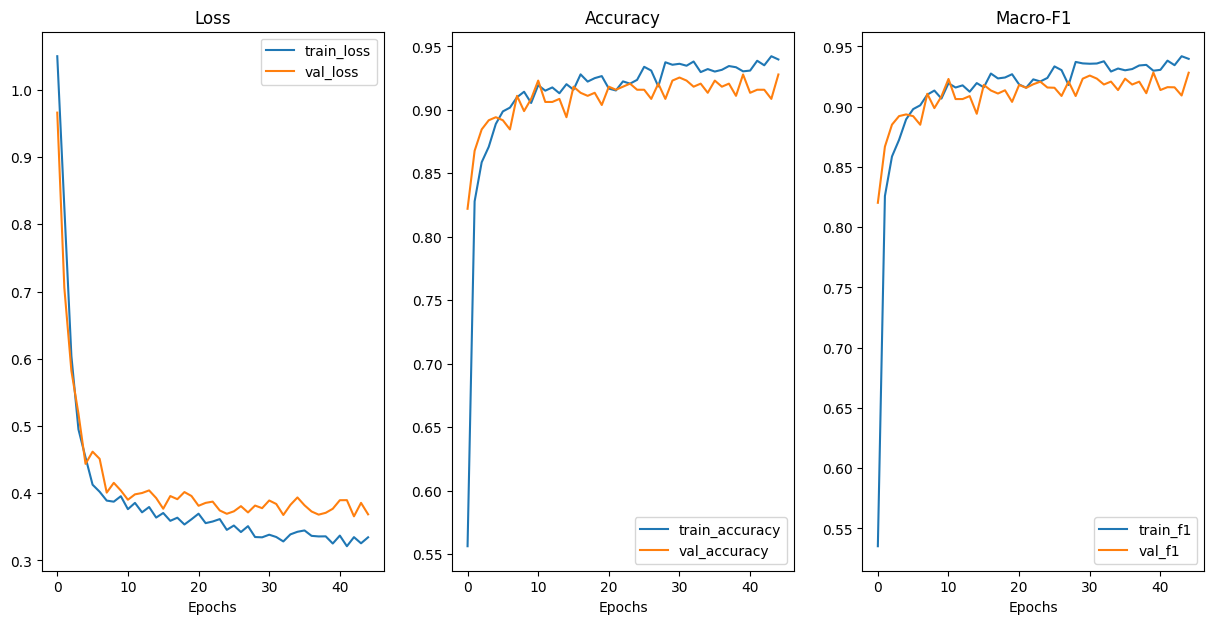

In [ ]:
plot_loss_curves(model_res)

Extracting EfficientNetV2's weights

In [ ]:
weights_ENv2S = torchvision.models.EfficientNet_V2_S_Weights.DEFAULT
model_ENv2S = torchvision.models.efficientnet_v2_s(weights=weights_ENv2S).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 113MB/s]


Model's description

In [ ]:
summary(model=model_ENv2S,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 384, 384]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 384, 384]    [32, 1280, 12, 12]   --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 384, 384]    [32, 24, 192, 192]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 384, 384]    [32, 24, 192, 192]   648                  True
│    │    └─BatchNorm2d (1)                                  [32, 24, 192, 192]   [32, 24, 192, 192]   48                   True
│    │    └─SiLU (2)                                         [32, 24, 192, 192]   [32, 24, 192, 192]   --                   --
│    └─Sequential (1)                                        [32, 24, 192, 192]   [32, 24, 192

Changing model's (efficientnet_v2_s) classifier

In [ ]:
tuning_model(model = model_ENv2S,
              in_features = 1280,
              out_features = 3,
              probability = 0.25,
             unfreezed_layers=2)

New efficientnet_v2_s description

In [ ]:
summary(model=model_ENv2S,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 384, 384]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 384, 384]    [32, 1280, 12, 12]   --                   Partial
│    └─Conv2dNormActivation (0)                              [32, 3, 384, 384]    [32, 24, 192, 192]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 384, 384]    [32, 24, 192, 192]   (648)                False
│    │    └─BatchNorm2d (1)                                  [32, 24, 192, 192]   [32, 24, 192, 192]   (48)                 False
│    │    └─SiLU (2)                                         [32, 24, 192, 192]   [32, 24, 192, 192]   --                   --
│    └─Sequential (1)                                        [32, 24, 192, 192]   [32

Loss, optimizer for efficientnet_v2_s

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

backbone_params, classifier_params = optimizer_params(model_ENv2S)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW([{'params': backbone_params, 'lr': 1e-5},
                               {'params': classifier_params, 'lr': 1e-3}],
                             weight_decay=5e-4)

Num epochs and lr_scheduler for efficientnet_v2_s

In [ ]:
num_epochs = 20 ## No need for a number > 10-15 because of the hard overfitting starting on 7-8th epoch

warmup_epochs = 2
warmup_steps = warmup_epochs * len(train_dataloader)
total_steps = num_epochs * len(train_dataloader)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.01,
    total_iters=warmup_steps)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=total_steps - warmup_steps,
    eta_min=1e-6
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps]
)

Training efficientnet_v2_s

In [ ]:
from timeit import default_timer as timer
start_time = timer()

model_res = train(model=model_ENv2S,
                  train_dataloader=train_dataloader,
                  val_dataloader=val_dataloader,
                  loss_fn=loss_fn,
                  optimizer=optimizer,
                  scheduler=scheduler,
                  num_epochs=num_epochs)
end_time = timer()

print(f"Total training time of efficientnet_v2_s: {end_time-start_time:.3f} seconds")

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0226 | train_acc: 0.5107 | val_loss: 0.8842 | val_acc: 0.8005 | train_f1: 0.4992 | val_f1: 0.7986 |
Epoch: 2 | train_loss: 0.6368 | train_acc: 0.8384 | val_loss: 0.4257 | val_acc: 0.9111 | train_f1: 0.8388 | val_f1: 0.9102 |
Epoch: 3 | train_loss: 0.4393 | train_acc: 0.8873 | val_loss: 0.3563 | val_acc: 0.9135 | train_f1: 0.8873 | val_f1: 0.9133 |
Epoch: 4 | train_loss: 0.3871 | train_acc: 0.9072 | val_loss: 0.3326 | val_acc: 0.9231 | train_f1: 0.9085 | val_f1: 0.9226 |
Epoch: 5 | train_loss: 0.3686 | train_acc: 0.9151 | val_loss: 0.3263 | val_acc: 0.9231 | train_f1: 0.9158 | val_f1: 0.9220 |
Epoch: 6 | train_loss: 0.3276 | train_acc: 0.9387 | val_loss: 0.3204 | val_acc: 0.9279 | train_f1: 0.9381 | val_f1: 0.9274 |
Epoch: 7 | train_loss: 0.3397 | train_acc: 0.9321 | val_loss: 0.3172 | val_acc: 0.9351 | train_f1: 0.9316 | val_f1: 0.9346 |
Epoch: 8 | train_loss: 0.3153 | train_acc: 0.9369 | val_loss: 0.3179 | val_acc: 0.9327 | train_f1: 0.9362 | val_f1: 0.9317 |


Plotting efficientnet_v2_s loss and accuracy

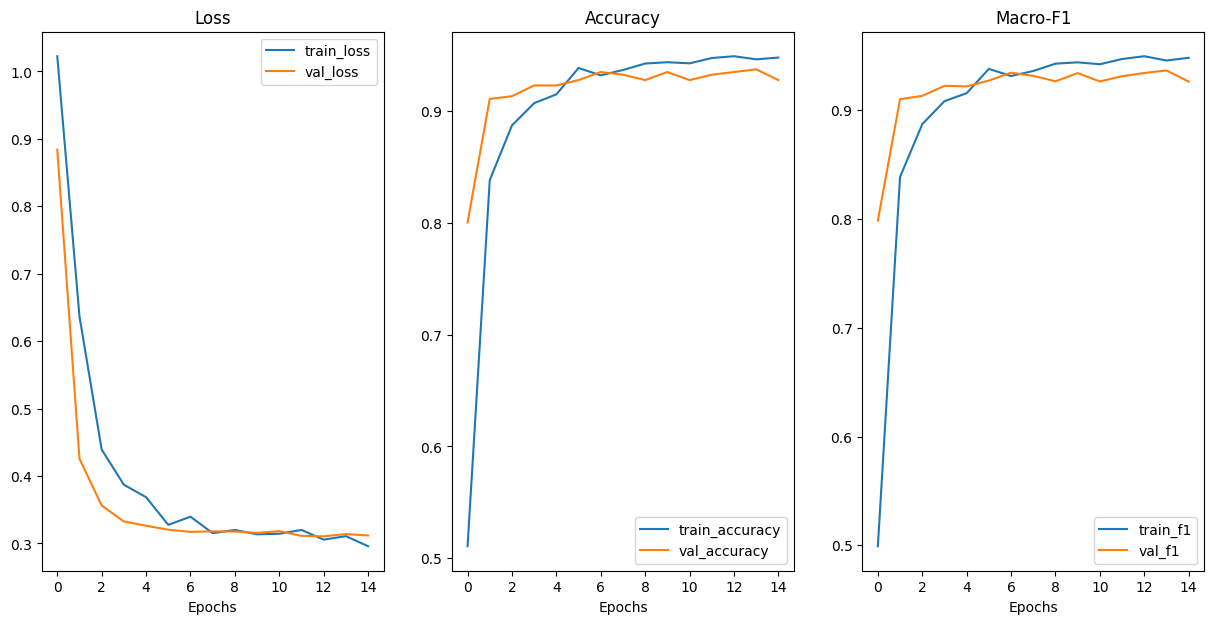

In [ ]:
plot_loss_curves(model_res)

Extracting ConvNextTiny's weights

In [ ]:
weights_CNxT = torchvision.models.ConvNeXt_Tiny_Weights.DEFAULT
model_CNxT = torchvision.models.convnext_tiny(weights=weights_CNxT).to(device)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 169MB/s]


Model's description

In [ ]:
summary(model=model_CNxT,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
ConvNeXt (ConvNeXt)                                     [32, 3, 384, 384]    [32, 1000]           --                   True
├─Sequential (features)                                 [32, 3, 384, 384]    [32, 768, 12, 12]    --                   True
│    └─Conv2dNormActivation (0)                         [32, 3, 384, 384]    [32, 96, 96, 96]     --                   True
│    │    └─Conv2d (0)                                  [32, 3, 384, 384]    [32, 96, 96, 96]     4,704                True
│    │    └─LayerNorm2d (1)                             [32, 96, 96, 96]     [32, 96, 96, 96]     192                  True
│    └─Sequential (1)                                   [32, 96, 96, 96]     [32, 96, 96, 96]     --                   True
│    │    └─CNBlock (0)                                 [32, 96, 96, 96]     [32, 96, 96, 96]     79,296               True
│  

Changing model's (ConvNextTiny) classifier

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for param in model_CNxT.features.parameters():
    param.requires_grad = False

for block in model_CNxT.features[-2::]:
    for param in block.parameters():
        param.requires_grad = True

model_CNxT.classifier = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.LayerNorm(768, eps=1e-6),
    torch.nn.Dropout(p=0.25),
    torch.nn.Linear(768, 3)
).to(device)

New ConvNextTiny description

In [ ]:
summary(model=model_CNxT,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
ConvNeXt (ConvNeXt)                                     [32, 3, 384, 384]    [32, 3]              --                   Partial
├─Sequential (features)                                 [32, 3, 384, 384]    [32, 768, 12, 12]    --                   Partial
│    └─Conv2dNormActivation (0)                         [32, 3, 384, 384]    [32, 96, 96, 96]     --                   False
│    │    └─Conv2d (0)                                  [32, 3, 384, 384]    [32, 96, 96, 96]     (4,704)              False
│    │    └─LayerNorm2d (1)                             [32, 96, 96, 96]     [32, 96, 96, 96]     (192)                False
│    └─Sequential (1)                                   [32, 96, 96, 96]     [32, 96, 96, 96]     --                   False
│    │    └─CNBlock (0)                                 [32, 96, 96, 96]     [32, 96, 96, 96]     (79,296)           

Loss, optimizer for ConvNextTiny

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

backbone_params, classifier_params = optimizer_params(model_CNxT)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW([{'params': backbone_params, 'lr': 1e-5},
                               {'params': classifier_params, 'lr': 1e-3}],
                             weight_decay=1e-4)

Num epochs and lr_scheduler for ConvNextTiny

In [ ]:
num_epochs = 12 ## No need in number > 10-15 because of overfitting around 7-8th epoch

warmup_epochs = 2
warmup_steps = warmup_epochs * len(train_dataloader)
total_steps = num_epochs * len(train_dataloader)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.01,
    total_iters=warmup_steps)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=total_steps - warmup_steps,
    eta_min=1e-6
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps]
)

Training ConvNextTiny

In [ ]:
from timeit import default_timer as timer
start_time = timer()

model_res = train(model=model_CNxT,
                  train_dataloader=train_dataloader,
                  val_dataloader=val_dataloader,
                  loss_fn=loss_fn,
                  optimizer=optimizer,
                  scheduler=scheduler,
                  num_epochs=num_epochs)
end_time = timer()

print(f"Total training time of ConvNextTiny: {end_time-start_time:.3f} seconds")

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9697 | train_acc: 0.5570 | val_loss: 0.5423 | val_acc: 0.8942 | train_f1: 0.5549 | val_f1: 0.8941 |
Epoch: 2 | train_loss: 0.4781 | train_acc: 0.8790 | val_loss: 0.3385 | val_acc: 0.9399 | train_f1: 0.8786 | val_f1: 0.9394 |
Epoch: 3 | train_loss: 0.3849 | train_acc: 0.9161 | val_loss: 0.3070 | val_acc: 0.9423 | train_f1: 0.9151 | val_f1: 0.9419 |
Epoch: 4 | train_loss: 0.3579 | train_acc: 0.9233 | val_loss: 0.3178 | val_acc: 0.9375 | train_f1: 0.9248 | val_f1: 0.9370 |
Epoch: 5 | train_loss: 0.3381 | train_acc: 0.9312 | val_loss: 0.3201 | val_acc: 0.9375 | train_f1: 0.9321 | val_f1: 0.9369 |
Epoch: 6 | train_loss: 0.3199 | train_acc: 0.9333 | val_loss: 0.3190 | val_acc: 0.9423 | train_f1: 0.9325 | val_f1: 0.9420 |
Epoch: 7 | train_loss: 0.3140 | train_acc: 0.9397 | val_loss: 0.3139 | val_acc: 0.9471 | train_f1: 0.9401 | val_f1: 0.9470 |
Epoch: 8 | train_loss: 0.3082 | train_acc: 0.9470 | val_loss: 0.3076 | val_acc: 0.9495 | train_f1: 0.9464 | val_f1: 0.9492 |


Plotting ConvNextTiny loss and accuracy

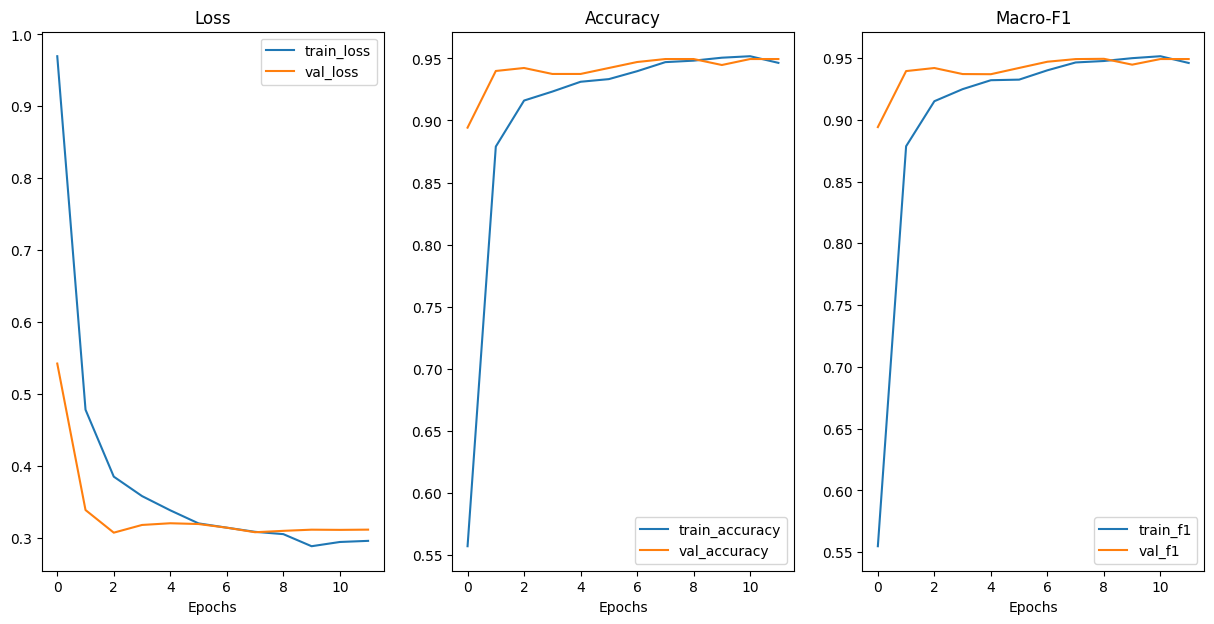

In [ ]:
plot_loss_curves(model_res)

Extracting Swin_V2_T weights

In [ ]:
weights_Sv2T = torchvision.models.Swin_V2_T_Weights.DEFAULT
model_Sv2T = torchvision.models.swin_v2_t(weights=weights_Sv2T).to(device)

Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth


100%|██████████| 109M/109M [00:00<00:00, 193MB/s] 


Model's description

In [ ]:
summary(model=model_Sv2T,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
SwinTransformer (SwinTransformer)                       [32, 3, 384, 384]    [32, 1000]           --                   True
├─Sequential (features)                                 [32, 3, 384, 384]    [32, 12, 12, 768]    --                   True
│    └─Sequential (0)                                   [32, 3, 384, 384]    [32, 96, 96, 96]     --                   True
│    │    └─Conv2d (0)                                  [32, 3, 384, 384]    [32, 96, 96, 96]     4,704                True
│    │    └─Permute (1)                                 [32, 96, 96, 96]     [32, 96, 96, 96]     --                   --
│    │    └─LayerNorm (2)                               [32, 96, 96, 96]     [32, 96, 96, 96]     192                  True
│    └─Sequential (1)                                   [32, 96, 96, 96]     [32, 96, 96, 96]     --                   True
│    

Changing model's (Swin_V2_T) classifier

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for param in model_Sv2T.features.parameters():
  param.requires_grad = False

for param in model_Sv2T.norm.parameters():
  param.requires_grad = True

for block in model_Sv2T.features[-1::]:
  for param in block.parameters():
    param.requires_grad = True

model_Sv2T.head = torch.nn.Sequential(
    torch.nn.Dropout(p=0.25),
    torch.nn.Linear(in_features=768,
                    out_features=3,
                    bias=True)).to(device)

New Swin_V2_T description

In [ ]:
summary(model=model_Sv2T,
        input_size=(32, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
SwinTransformer (SwinTransformer)                       [32, 3, 384, 384]    [32, 3]              --                   Partial
├─Sequential (features)                                 [32, 3, 384, 384]    [32, 12, 12, 768]    --                   Partial
│    └─Sequential (0)                                   [32, 3, 384, 384]    [32, 96, 96, 96]     --                   False
│    │    └─Conv2d (0)                                  [32, 3, 384, 384]    [32, 96, 96, 96]     (4,704)              False
│    │    └─Permute (1)                                 [32, 96, 96, 96]     [32, 96, 96, 96]     --                   --
│    │    └─LayerNorm (2)                               [32, 96, 96, 96]     [32, 96, 96, 96]     (192)                False
│    └─Sequential (1)                                   [32, 96, 96, 96]     [32, 96, 96, 96]     --                   F

Loss, optimizer for Swin_V2_T

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

backbone_params, classifier_params = optimizer_params(model_Sv2T)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW([{'params': backbone_params, 'lr': 1e-5},
                               {'params': classifier_params, 'lr': 1e-3}],
                             weight_decay=1e-4)

Num epochs and lr_scheduler for Swin_V2_T

In [ ]:
num_epochs = 20

warmup_epochs = 2
warmup_steps = warmup_epochs * len(train_dataloader)
total_steps = num_epochs * len(train_dataloader)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.01,
    total_iters=warmup_steps)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=total_steps - warmup_steps,
    eta_min=1e-6
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps]
)

Training Swin_V2_T

In [ ]:
from timeit import default_timer as timer
start_time = timer()

model_res = train(model=model_Sv2T,
                  train_dataloader=train_dataloader,
                  val_dataloader=val_dataloader,
                  loss_fn=loss_fn,
                  optimizer=optimizer,
                  scheduler=scheduler,
                  num_epochs=num_epochs)
end_time = timer()

print(f"Total training time of Swin_V2_T: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9221 | train_acc: 0.6107 | val_loss: 0.5973 | val_acc: 0.8870 | train_f1: 0.6069 | val_f1: 0.8816 |
Epoch: 2 | train_loss: 0.4582 | train_acc: 0.9022 | val_loss: 0.3943 | val_acc: 0.9159 | train_f1: 0.9020 | val_f1: 0.9138 |
Epoch: 3 | train_loss: 0.3959 | train_acc: 0.9042 | val_loss: 0.3381 | val_acc: 0.9327 | train_f1: 0.9028 | val_f1: 0.9313 |
Epoch: 4 | train_loss: 0.3592 | train_acc: 0.9241 | val_loss: 0.3021 | val_acc: 0.9495 | train_f1: 0.9248 | val_f1: 0.9484 |
Epoch: 5 | train_loss: 0.3460 | train_acc: 0.9196 | val_loss: 0.3080 | val_acc: 0.9423 | train_f1: 0.9187 | val_f1: 0.9413 |
Epoch: 6 | train_loss: 0.3396 | train_acc: 0.9256 | val_loss: 0.2955 | val_acc: 0.9567 | train_f1: 0.9251 | val_f1: 0.9562 |
Epoch: 7 | train_loss: 0.3359 | train_acc: 0.9302 | val_loss: 0.2946 | val_acc: 0.9591 | train_f1: 0.9301 | val_f1: 0.9587 |
Epoch: 8 | train_loss: 0.3288 | train_acc: 0.9327 | val_loss: 0.3091 | val_acc: 0.9423 | train_f1: 0.9322 | val_f1: 0.9420 |


Plotting Swin_V2_T loss and accuracy

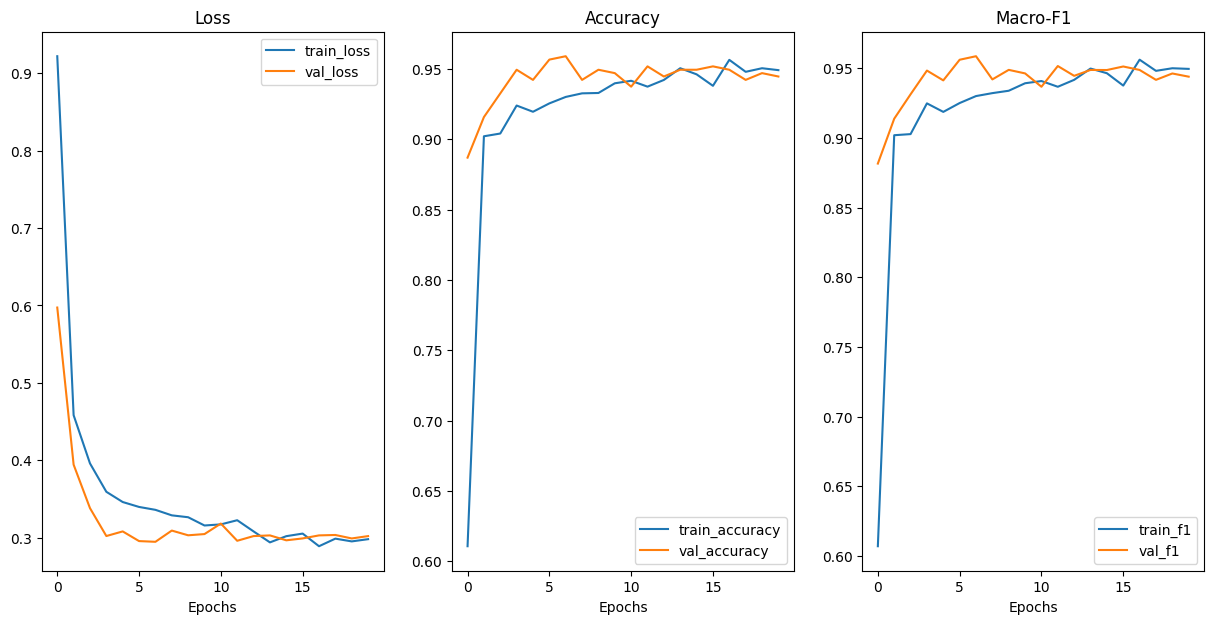

In [ ]:
plot_loss_curves(model_res)

Creating Custom Dataset for test data

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class WeatherTestDataset(Dataset):
  def __init__(self, img_dir, transform=None):
    self.img_dir = img_dir
    self.img_paths = sorted(list(self.img_dir.glob('*.png')))
    self.transform = transform

  def __len__(self):
    return len(self.img_paths)

  def __getitem__(self, idx):
    img_path = self.img_paths[idx]

    img = Image.open(img_path).convert('RGB')
    if self.transform:
      img = self.transform(img)
    return img, img_path.name

Test dataset and dataloader for basic images

In [ ]:
test_base_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_base_dataset = WeatherTestDataset(test_dir, test_base_transform)

test_base_dataloader = DataLoader(test_base_dataset, batch_size=64, shuffle=False)

print('Class to index:', train_dataset.class_to_idx)

Class to index: {'fog': 0, 'rain': 1, 'snow': 2}


Test dataset and dataloader for flipped images

In [ ]:
test_flip_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_flip_dataset = WeatherTestDataset(test_dir, test_flip_transform)

test_flip_dataloader = DataLoader(test_flip_dataset, batch_size=64, shuffle=False)

print('Class to index:', train_dataset.class_to_idx)

Class to index: {'fog': 0, 'rain': 1, 'snow': 2}


Test dataset and test dataloader for images with ColorJitter+Rotation

In [ ]:
test_color_rotate_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.05,
                           contrast=0.05,
                           saturation=0.05,
                           hue=0.01),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_color_rotate_dataset = WeatherTestDataset(test_dir, test_color_rotate_transform)

test_color_rotate_dataloader = DataLoader(test_color_rotate_dataset, batch_size=64, shuffle=False)

print('Class to index:', train_dataset.class_to_idx)

Class to index: {'fog': 0, 'rain': 1, 'snow': 2}


Test dataset and dataloader for images with ColorJitter+Flip+Rotation

In [ ]:
test_color_rotate_flip_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.05,
                           contrast=0.05,
                           saturation=0.05,
                           hue=0.01),
    transforms.RandomRotation(degrees=5),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_color_rotate_flip_dataset = WeatherTestDataset(test_dir, test_color_rotate_flip_transform)

test_color_rotate_flip_dataloader = DataLoader(test_color_rotate_flip_dataset, batch_size=64, shuffle=False)

print('Class to index:', train_dataset.class_to_idx)

Class to index: {'fog': 0, 'rain': 1, 'snow': 2}


Predicting basic and flipped test data

In [ ]:
model_ENb4.to(device).eval()
model_ENv2S.to(device).eval()
model_CNxT.to(device).eval()
model_Sv2T.to(device).eval()
probs_base_dict = {}
probs_flip_dict = {}
probs_color_rotate_dict = {}
probs_color_rotate_flip_dict = {}

with torch.inference_mode():
  for images, names in tqdm(test_base_dataloader, desc='Base Predicting'):
    images = images.to(device)

    outputs_ENb4 = model_ENb4(images)
    probs_ENb4 = torch.softmax(outputs_ENb4, dim=1)

    outputs_ENv2S = model_ENv2S(images)
    probs_ENv2S = torch.softmax(outputs_ENv2S, dim=1)

    outputs_CNxT = model_CNxT(images)
    probs_CNxT = torch.softmax(outputs_CNxT, dim=1)

    outputs_Sv2T = model_Sv2T(images)
    probs_Sv2T = torch.softmax(outputs_Sv2T, dim=1)

    probs = (probs_ENb4+probs_ENv2S+probs_CNxT+probs_Sv2T)/4

    for name, prob in zip(names, probs):
      probs_base_dict[name] = prob.cpu().numpy()


  for images, names in tqdm(test_flip_dataloader, desc='Flip Predicting'):
    images = images.to(device)

    outputs_ENb4 = model_ENb4(images)
    probs_ENb4 = torch.softmax(outputs_ENb4, dim=1)

    outputs_ENv2S = model_ENv2S(images)
    probs_ENv2S = torch.softmax(outputs_ENv2S, dim=1)

    outputs_CNxT = model_CNxT(images)
    probs_CNxT = torch.softmax(outputs_CNxT, dim=1)

    outputs_Sv2T = model_Sv2T(images)
    probs_Sv2T = torch.softmax(outputs_Sv2T, dim=1)

    probs = (probs_ENb4+probs_ENv2S+probs_CNxT+probs_Sv2T)/4

    for name, prob in zip(names, probs):
      probs_flip_dict[name] = prob.cpu().numpy()


  for images, names in tqdm(test_color_rotate_dataloader, desc='ColorJitter+Rotate Predicting'):
    images = images.to(device)

    outputs_ENb4 = model_ENb4(images)
    probs_ENb4 = torch.softmax(outputs_ENb4, dim=1)

    outputs_ENv2S = model_ENv2S(images)
    probs_ENv2S = torch.softmax(outputs_ENv2S, dim=1)

    outputs_CNxT = model_CNxT(images)
    probs_CNxT = torch.softmax(outputs_CNxT, dim=1)

    outputs_Sv2T = model_Sv2T(images)
    probs_Sv2T = torch.softmax(outputs_Sv2T, dim=1)

    probs = (probs_ENb4+probs_ENv2S+probs_CNxT+probs_Sv2T)/4

    for name, prob in zip(names, probs):
      probs_color_rotate_dict[name] = prob.cpu().numpy()

  for images, names in tqdm(test_color_rotate_flip_dataloader, desc='ColorJitter+Rotate+Flip Predicting'):
    images = images.to(device)

    outputs_ENb4 = model_ENb4(images)
    probs_ENb4 = torch.softmax(outputs_ENb4, dim=1)

    outputs_ENv2S = model_ENv2S(images)
    probs_ENv2S = torch.softmax(outputs_ENv2S, dim=1)

    outputs_CNxT = model_CNxT(images)
    probs_CNxT = torch.softmax(outputs_CNxT, dim=1)

    outputs_Sv2T = model_Sv2T(images)
    probs_Sv2T = torch.softmax(outputs_Sv2T, dim=1)

    probs = (probs_ENb4+probs_ENv2S+probs_CNxT+probs_Sv2T)/4

    for name, prob in zip(names, probs):
      probs_color_rotate_flip_dict[name] = prob.cpu().numpy()

Base Predicting:   0%|          | 0/23 [00:00<?, ?it/s]

Flip Predicting:   0%|          | 0/23 [00:00<?, ?it/s]

ColorJitter+Rotate Predicting:   0%|          | 0/23 [00:00<?, ?it/s]

ColorJitter+Rotate+Flip Predicting:   0%|          | 0/23 [00:00<?, ?it/s]

**Averaging** predictions

In [ ]:
preds_dict = {}
for name in probs_base_dict:
  avg_probs = (probs_base_dict[name]+probs_flip_dict[name]+probs_color_rotate_dict[name]+probs_color_rotate_flip_dict[name])/4
  pred_class = np.argmax(avg_probs)
  preds_dict[name] = pred_class

Creating submission

In [ ]:
sample_sub = pd.read_csv('sample_submission.csv')
sample_sub.head()

,id,label
0,0.png,0
1,1.png,0
2,2.png,0
3,3.png,0
4,5.png,0


In [ ]:
sample_sub['label'] = sample_sub['id'].map(preds_dict)

if sample_sub['label'].isna().any():
    missing_ids = sample_sub[sample_sub['label'].isna()]['id'].tolist()
    print(f"WARNING: {len(missing_ids)} IDs from sample_submission were not found in test folder!")
    print(f"Missing: {missing_ids[:5]}...")
else:
    print("All IDs matched successfully!")

official_mapping = {0: 1, 1: 0, 2: 2}
sample_sub['label'] = sample_sub['label'].map(official_mapping)

sample_sub.to_csv('submission.csv', index=False)
display(sample_sub.head())

All IDs matched successfully!


,id,label
0,0.png,1
1,1.png,2
2,2.png,1
3,3.png,1
4,5.png,0


Saving weights for future

In [ ]:
torch.save(model_ENb4.state_dict(), 'best_ENb4.pth')
torch.save(model_ENv2S.state_dict(), 'best_ENv2S.pth')
torch.save(model_CNxT.state_dict(), 'best_CNxT.pth')
torch.save(model_Sv2T.state_dict(), 'best_Sv2T.pth')